# Classification(분류) 모델
- 대표적인 지도학습
- 분류모델
    - 로지스틱 회귀(logistic Regression) - 최근에는 분류모델에 더 가깝다고 봄
        - Sigmoid Function : 어떤 숫자가 들어와도 결과를 0과 1사이의 값으로 바꿔주는 함수를 기반으로 한 모델
    - Decision Tree(의사결정트리)
    - Random Forest - 현장에서 가장 많이 사용하는 분류모델
    - SVM(Support vector machine)
      - 데이터와 클래스 사이의 경계를 찾아서 분류
      - 데이터 포인트들을 고차원 공간으로 매핑하여 decision Boundary(결정경계)를찾고
      - 이를 통해서 데이터를 분류하거나 예측
      - Margin(DB 결정 경계와 가장 가까운 데이터 포인트 사이의 거리)을 가진 Decision Boundary(결정경계)를 찾음
      - Margin을 최대화하는 Decision Boundary를 찾고자 하는 모데링 바로 SVM

In [67]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

#머신러
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [68]:
iris = load_iris()

In [69]:
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)

In [70]:
iris_df['target'] = iris.target

In [71]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [72]:
#y = df['petal width (cm)']
#X = df.drop(['petal width (cm)'], axis = 1)

In [117]:
iris_df['species'] = iris_df['target'].map({
    0 : iris.target_names[0],
    1 : iris.target_names[1],
    2 : iris.target_names[2]
})

y = iris_df['species']
X = iris_df[['petal length (cm)','petal width (cm)','petal length (cm)', 'petal width (cm)']]

Train/Test split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify =y
)

In [119]:
y_train.shape

(120,)

In [120]:
X_train.shape

(120, 4)

In [121]:
model = DecisionTreeClassifier(
    max_depth = 3, #트리의 최대 깊이 제한
    random_state = 42)

In [122]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [123]:
y_pred = model.predict(X_test)
#t_test.values
print(y_pred)

[np.str_('setosa') np.str_('virginica') np.str_('versicolor')
 np.str_('versicolor') np.str_('setosa') np.str_('versicolor')
 np.str_('setosa') np.str_('setosa') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('virginica')
 np.str_('virginica') np.str_('versicolor') np.str_('setosa')
 np.str_('setosa') np.str_('setosa') np.str_('versicolor')
 np.str_('versicolor') np.str_('virginica') np.str_('setosa')
 np.str_('virginica') np.str_('versicolor') np.str_('virginica')
 np.str_('virginica') np.str_('virginica') np.str_('versicolor')
 np.str_('setosa') np.str_('virginica') np.str_('setosa')]


# 모델평가

In [124]:
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree 정확도: ",round(accuracy,3))

Decision Tree 정확도:  0.967


# 분류모델성능 report

In [125]:
print(classification_report(
    y_test,
    y_pred,
    target_names = iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



[분류모델의 핵심 평가지표]

0. Accuracy : 전체 데이터 중 모델이 맞게 예측한 비율 > 전체 문제 중 몇개를 맞혔는가?
1. precision : 모델이 해당 품종이라고 예측한것 중 실제로 맞은 비율 > setosa라고 예측한 것중 진짜로 setosa는 몇개인가
2. recall : 실제 해당 품종 중 모델이 제대로 맞힌 비율 > 진짜 setosa 중에서 모델이 setosa로 맞힌 것은 몇개인가
3. f1-score : precision과 recall을 종합한 조화 평균 점수
4. support : 실제 데이터 개수

# decision Tree 구조 시각화 분석

In [126]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

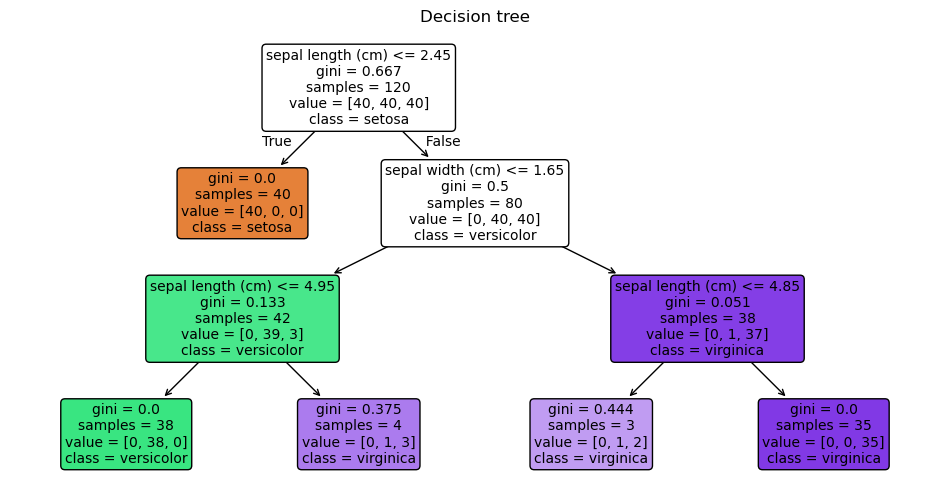

In [127]:
plt.figure(figsize= (12,6))
plot_tree(model, 
         feature_names = iris.feature_names, #가장 잘 분류돠는 feature로 모델이 알아서 골라서 분류 수행
         class_names = iris.target_names,
         filled = True,
         rounded = True,
         fontsize = 10)

plt.title('Decision tree')
plt.show()

- petal length (cm) <= 2.45 : 분류조건 : 꽃잎 길이가 2.45이하인가
- gini : 불순도 : 데이터가 얼마나 섞여 있는가
    - gini : 데이터가 얼마나 잘 섞여 있는지 나타냄
    - gini = 0 : 한 종류만 있음, 깨끗하게 분류되어 있음, but gini가 클수록 여러 종류가 섞여 있음
- samples : 데이터 개수 이 노드에 들어온 데이터 수
- value : 클래스별 데이터 개수 : setosa, versicolor, viginica 각각 몇개인가
- class : 대표 예측 클래스 : 이 노드에서 가장 많은 품종

# feature importance 분석

In [130]:
importance = pd.DataFrame({
    "feature" : iris.feature_names,
    "importance" : model.feature_importances_})
# scikit_learn 에서 학습 후 생기는 값의이름끝에 _ 붙이는 경향이 존재함

importance = importance.sort_values(
    by = "importance",
    ascending = True
)

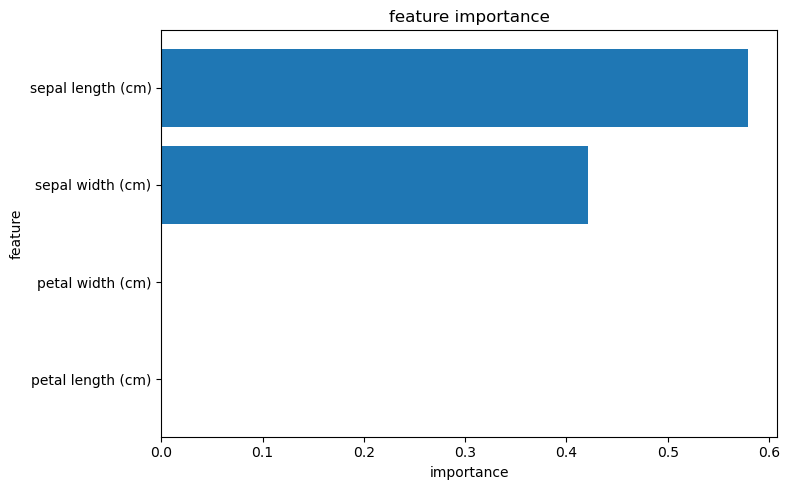

In [132]:
plt.figure(figsize = (8,5))

plt.barh(
    importance['feature'],
    importance['importance']
) 

plt.xlabel('importance')
plt.ylabel("feature")
plt.title("feature importance")

#plt.gca().invert_yaxis()# x축과 y축 순서를 뒤집음
plt.tight_layout()
plt.show()